In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina' # high res plotting

import sys
sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/spikeparam')
sys.path.append(('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/'))
sys.path.append(('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/datasets/spe-1/spe1_helper_modules/'))
sys.path.append(('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/datasets/shared_helper_modules'))

# General imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import warnings
import pickle
from specparam import SpectralModel
from specparam import Bands
import neurodsp as ndp
from scipy.stats import zscore

# NeuroDSP scipy and FOOOF modules
from neurodsp import spectral




#  modules
from lfp_spike_window_analysis import *

from spe1_plotting import *
from signal_utils import * 
from spikeparam.patch.fit import Spike

from config import NPX_CHANNELS, CELL_IDS, DICT_PATCH_FS, DICT_CHAN_PRED, DICT_SPK_THRESH, FILTER_SETTINGS

### Set up

In [3]:
cell_num =42 #MODIFY THIS WHEN RUNNING DIFFERENT CELLS 

npx_fs = 30000 # sampling rate
lfp_fs = 2500 # sampling rate

patch_fs = DICT_PATCH_FS[cell_num ]
spk_thresh = DICT_SPK_THRESH[cell_num]

npx_channels = NPX_CHANNELS
npx_patch_channel = DICT_CHAN_PRED[cell_num ]

#### Step 0: Get loaded data

In [4]:
lfp_dir= '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_lfp_recordings/c42_lfp_filt.npy'
patch_dir= '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_patch_recordings/c42patch_filt.npy'

In [5]:
#get cell number 
cell_num = lfp_dir.split('/')[len(lfp_dir.split('/'))-1].split('_')[0]

#get LFP data
lfp_filt = np.load(lfp_dir)
lfp_one_ms = float(lfp_fs / 1000)
lfp_times = np.arange(0, np.shape(lfp_filt)[0]) / lfp_one_ms # in ms instead of sec

#get patch data 
patch_filt = np.load(patch_dir)
patch_one_ms = float(patch_fs  / 1000)
patch_times = np.arange(0, np.shape(patch_filt )[0]) / patch_one_ms # in ms instead of sec

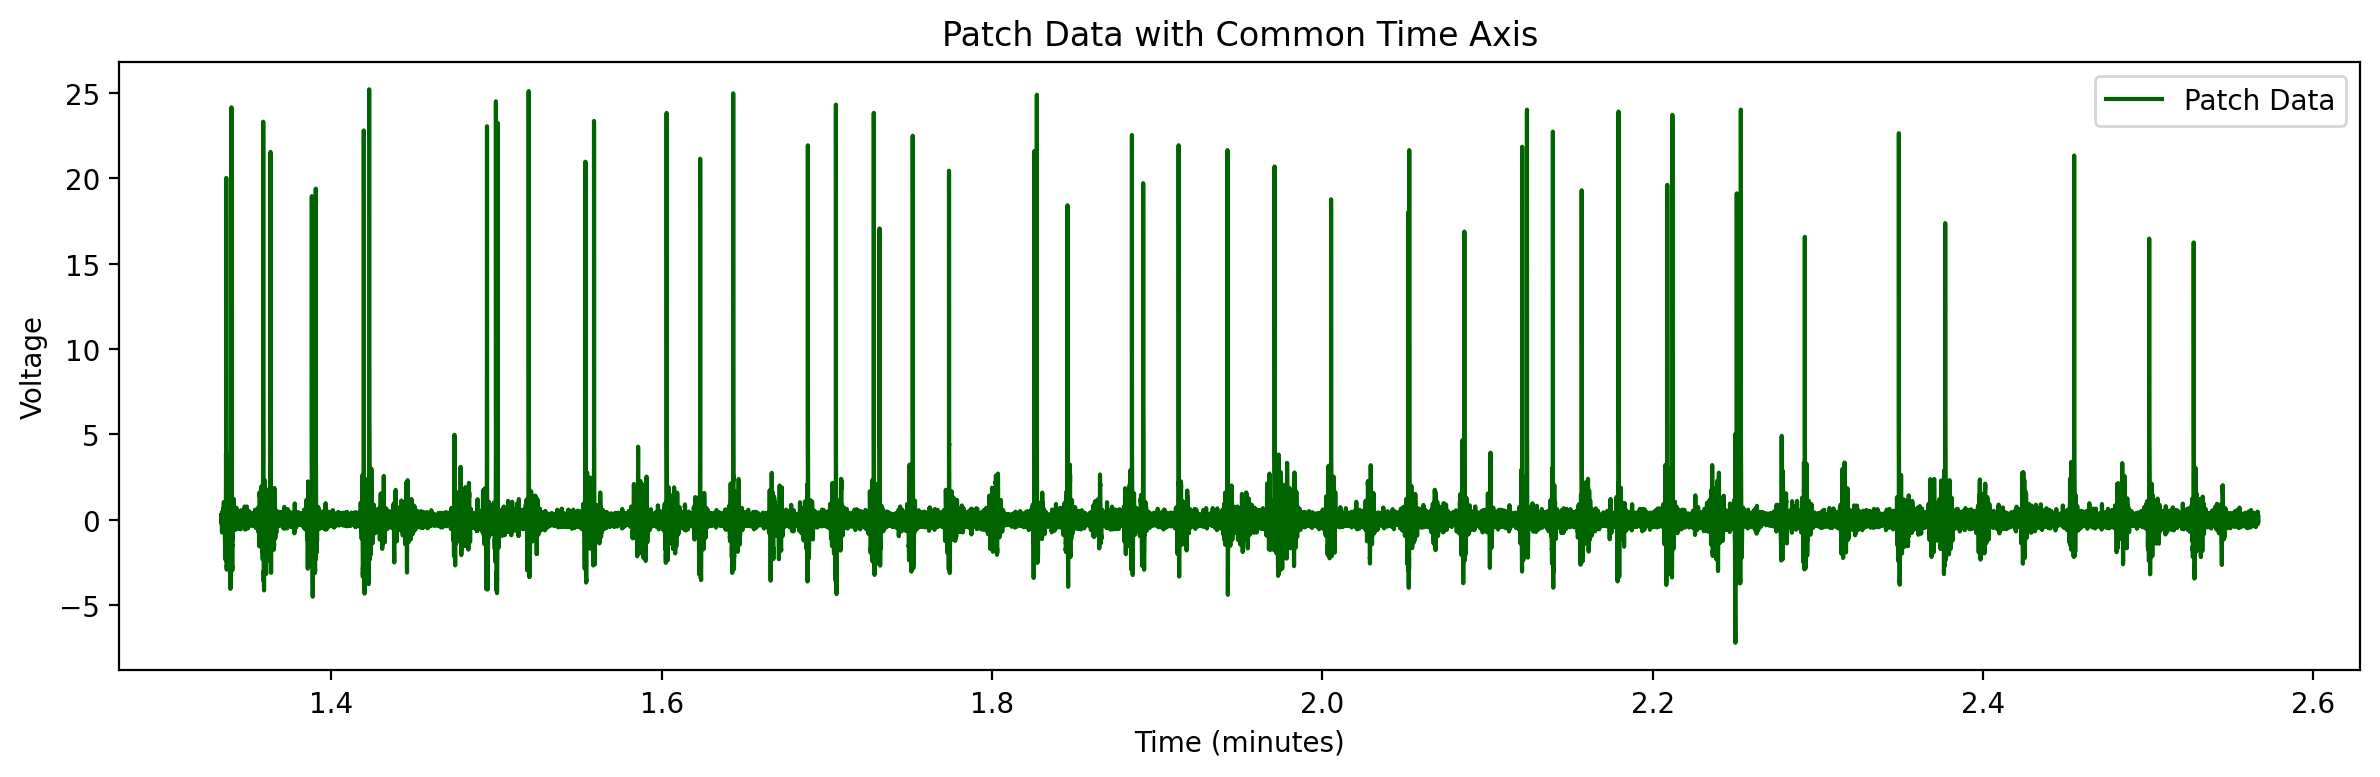

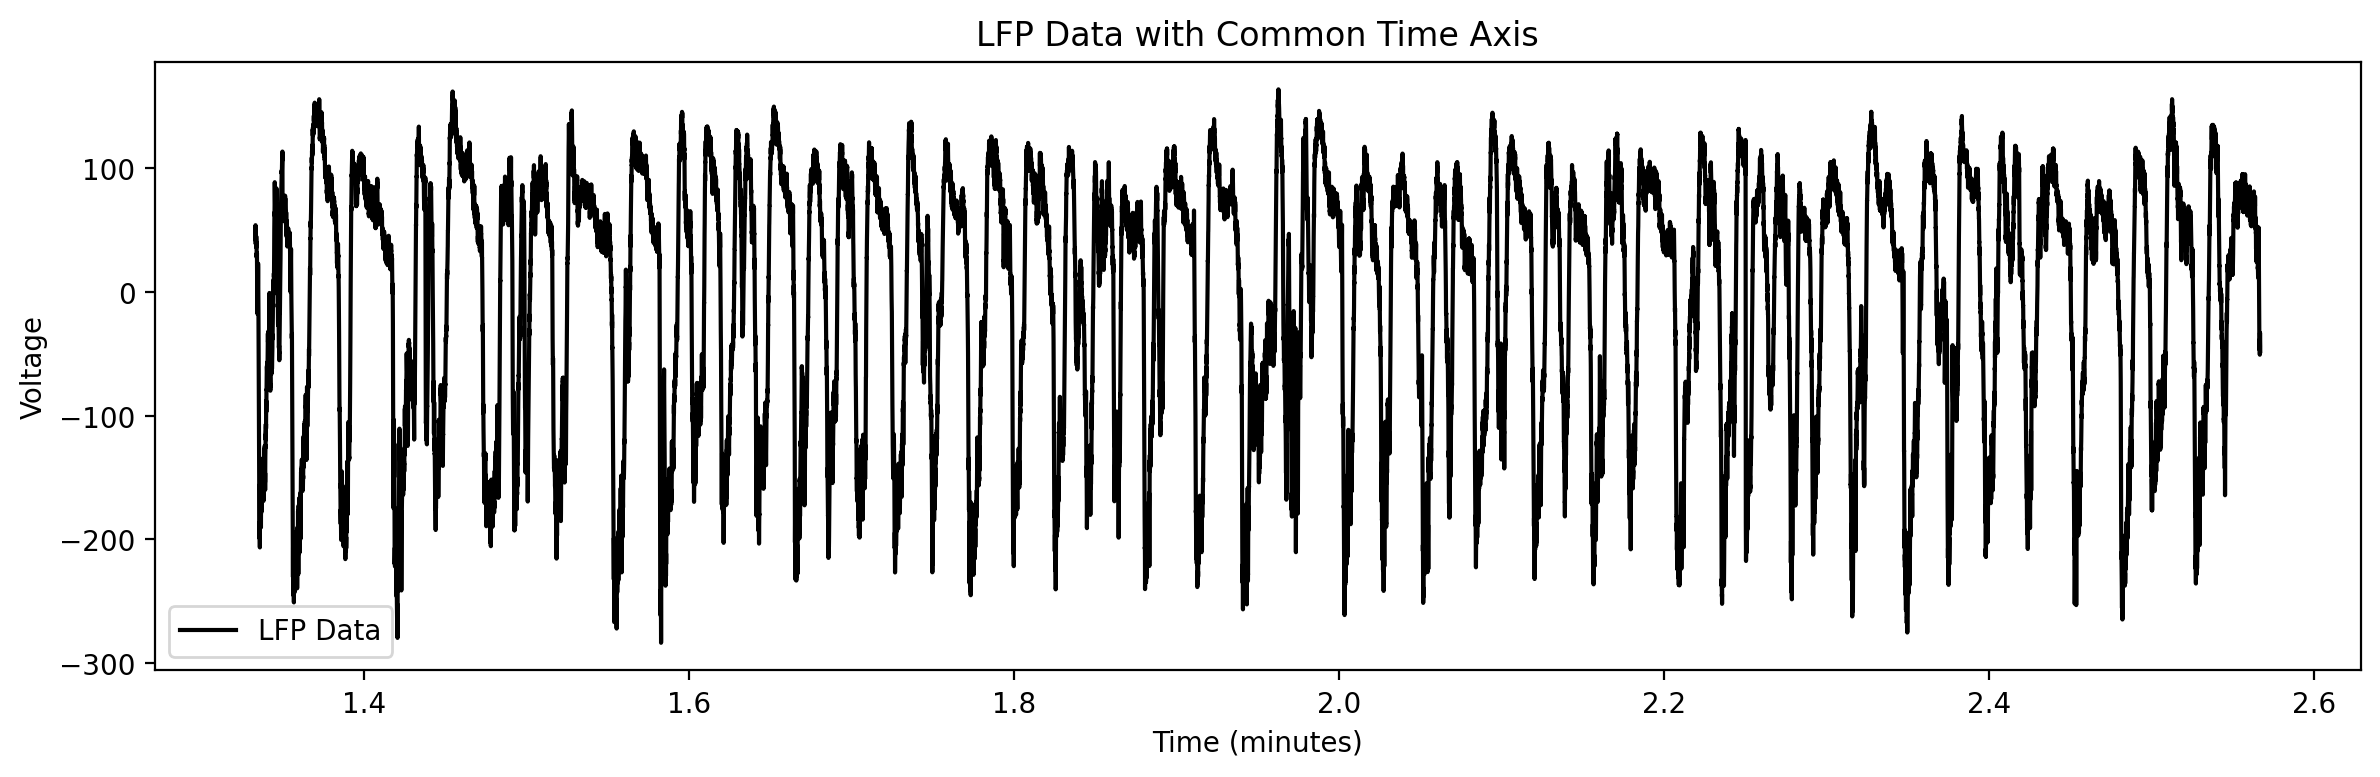

In [6]:
_ =  plot_patch_lfp_aligned(
    patch_times, patch_filt, lfp_times, lfp_filt,
    t_start_ms=80000, t_end_ms=154000
)


## STEP 1: ANALYZE LFP DATA

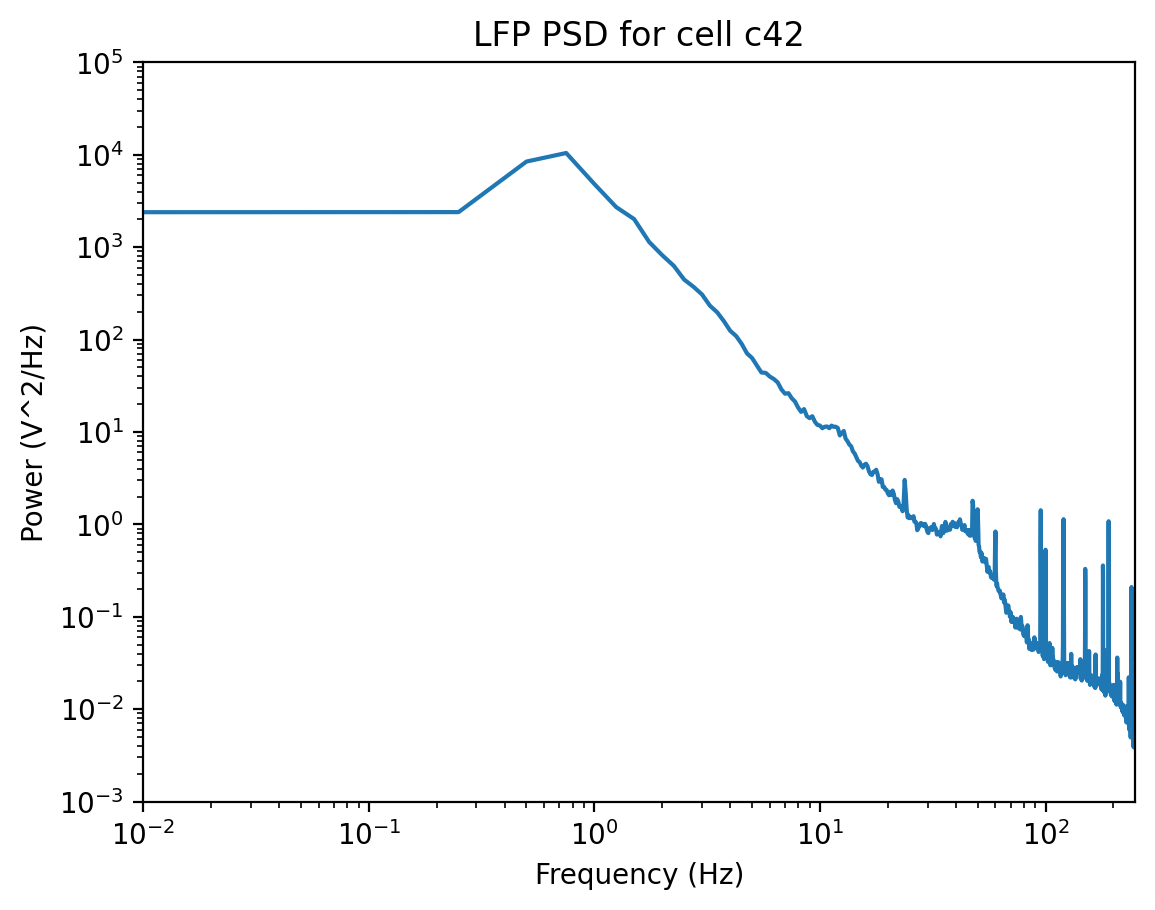

In [7]:

# plot power spectrum
fxx, pxx = spectral.compute_spectrum(lfp_filt, lfp_fs, method='welch', window='hann', nperseg=lfp_fs*4)

xlim = (10e-3, 250)
ylim = (10e-4, 10e4)
plt.loglog(fxx, pxx)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power (V^2/Hz)')
plt.xlim(xlim)
plt.ylim(ylim)
plt.title("LFP PSD for cell "+ cell_num)
plt.show()


### There seem to be some gamma oscillations 

#### Use specpram to find gamma peaks

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


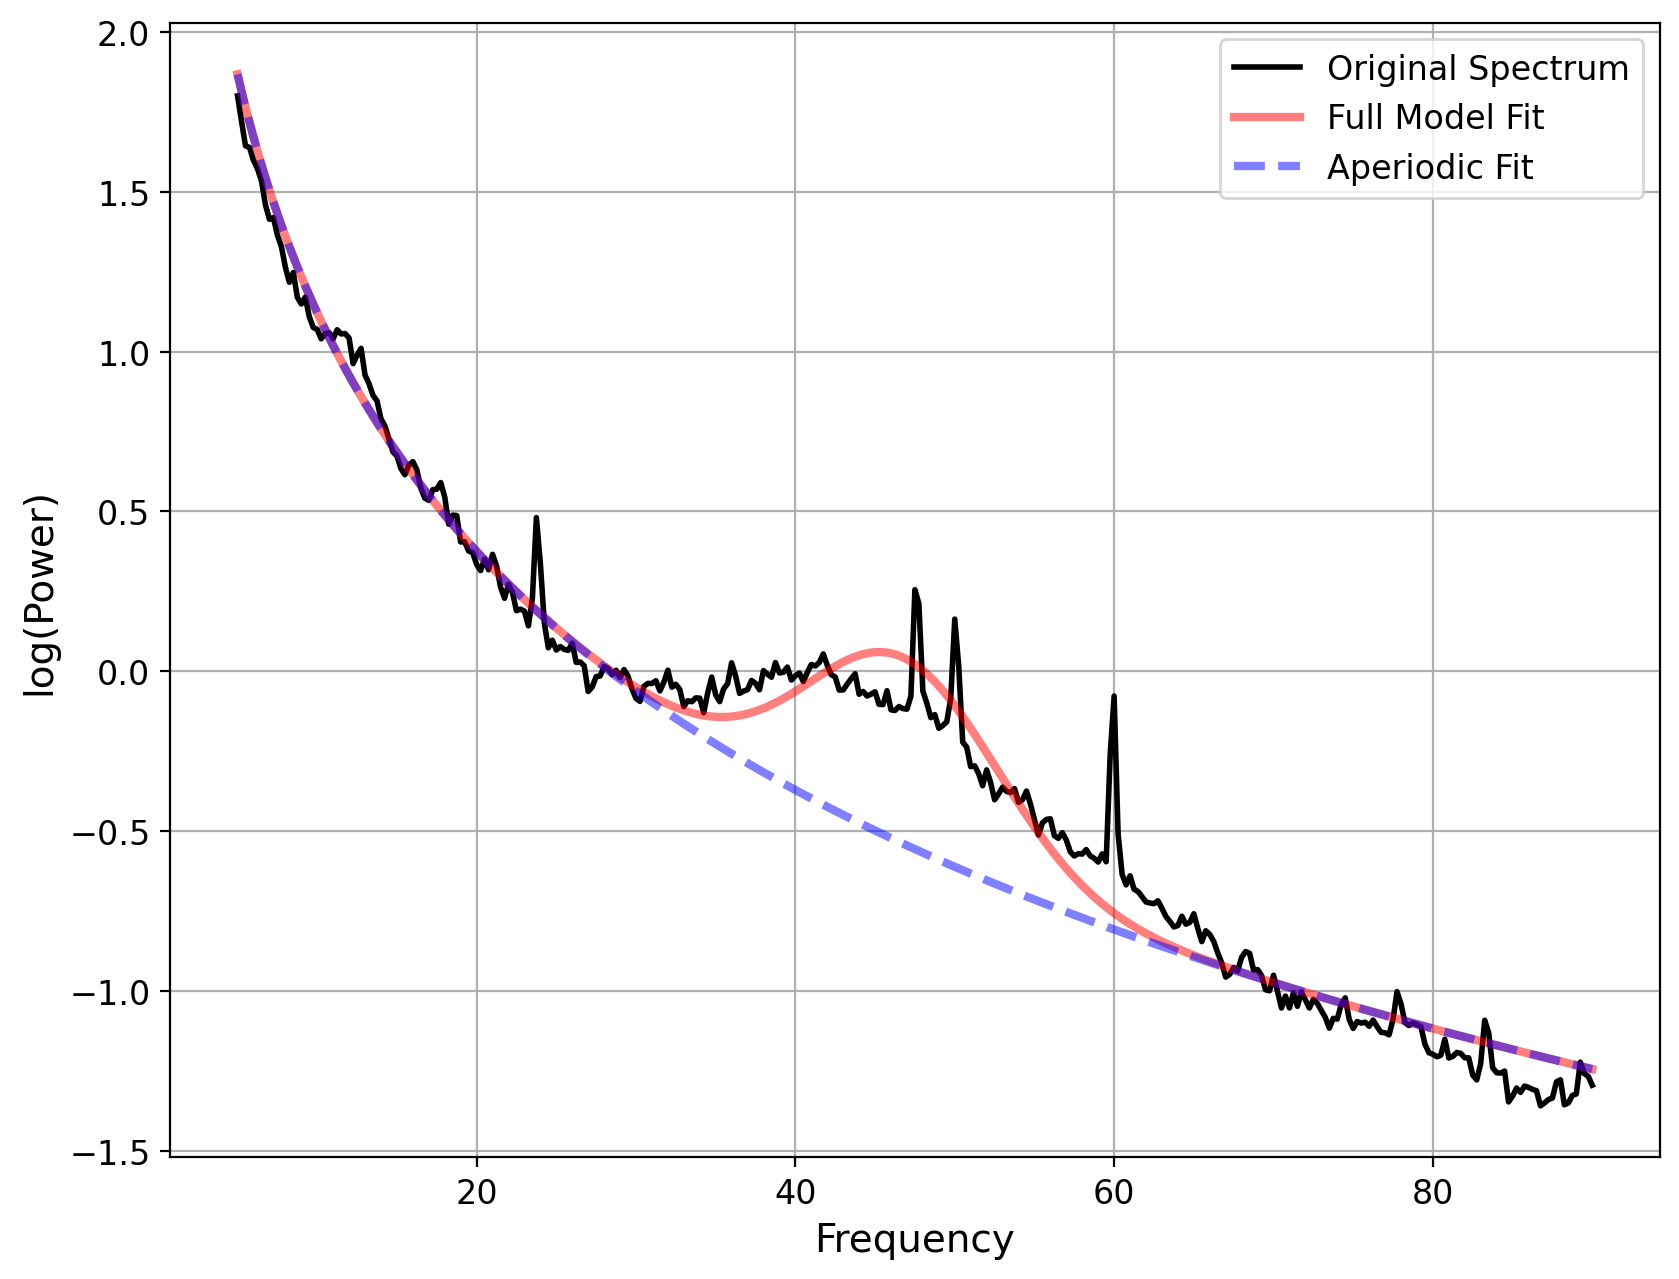

In [8]:
fm = SpectralModel(max_n_peaks=1, verbose=False)
fm.fit(fxx, pxx, freq_range=(5,90))
fm.plot()

# A) Long window specparam classification for kilosort

In [9]:

# SHARED PARAMETERS
lfp_signal = lfp_filt
fs = lfp_fs

# Windowing parameters
window_len_sec = 2
step_size_sec = 1

# Specparam fitting options
fooof_params = {"max_n_peaks": 4, "peak_width_limits": (4, 8), "verbose": False}


In [10]:
# Define a bands object to organize peak parameters
bands = Bands({'gamma' : [30, 90]})

In [11]:
# ---- Compute Welch-based model ----
model_welch, freqs_welch, win_times_welch = compute_lfp_windows(
    lfp_signal=lfp_signal,
    fs=fs,
    method="welch",
    window_length_sec=window_len_sec,
    step_size_sec=step_size_sec,
    freq_range=(1, 90),
    fooof_params=fooof_params,
    welch_params={"window": "hann", "nperseg": int(fs)}
)



                                                                                                  
                                           TIME RESULTS                                           
                                                                                                  
                                 Number of time windows fit: 809                                  
                                                                                                  
                        The model was run on the frequency range 1 - 90 Hz                        
                                 Frequency Resolution is 1.00 Hz                                  
                                                                                                  
                              Power spectra were fit without a knee.                              
                                                                                                  
          

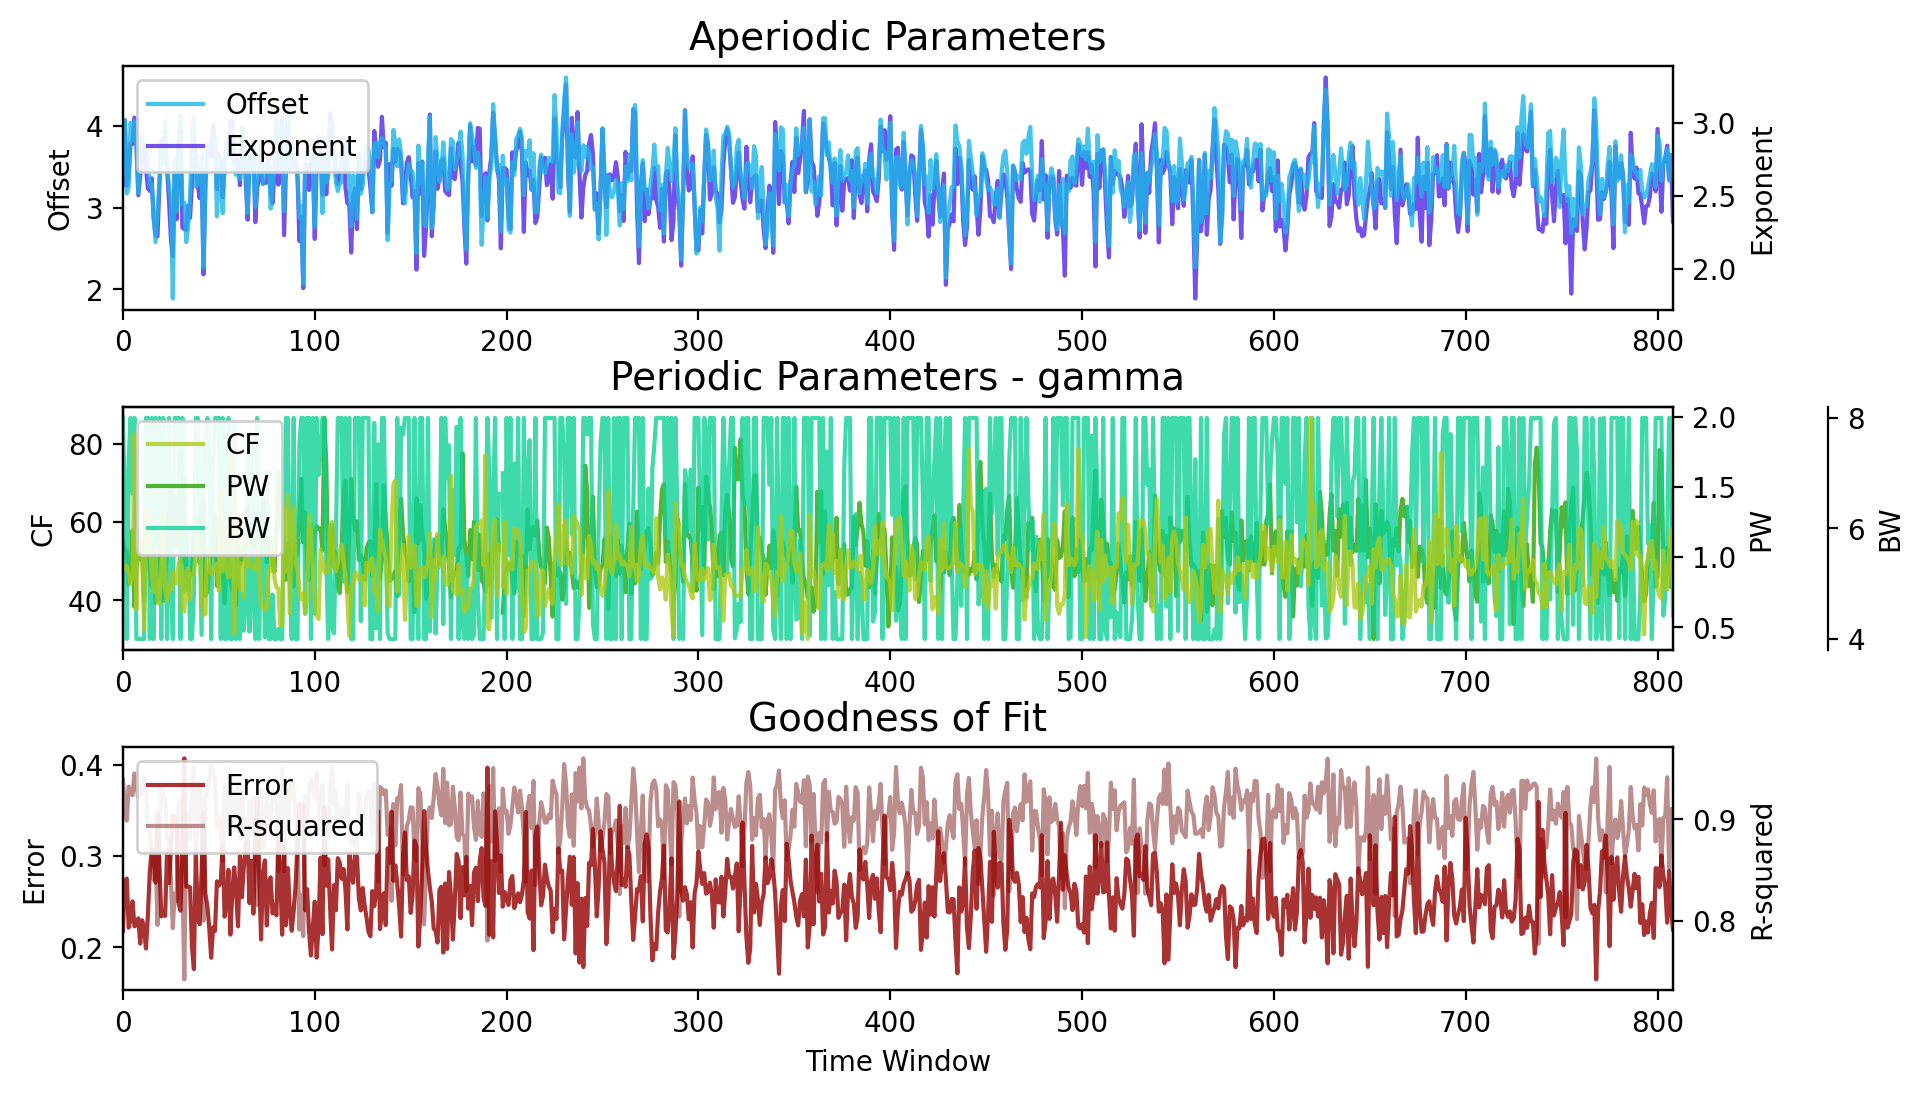

In [12]:
model_welch.report(peak_org=bands)

In [13]:
# Get summary df
summary_df_welch = model_welch.to_df(peak_org=bands)

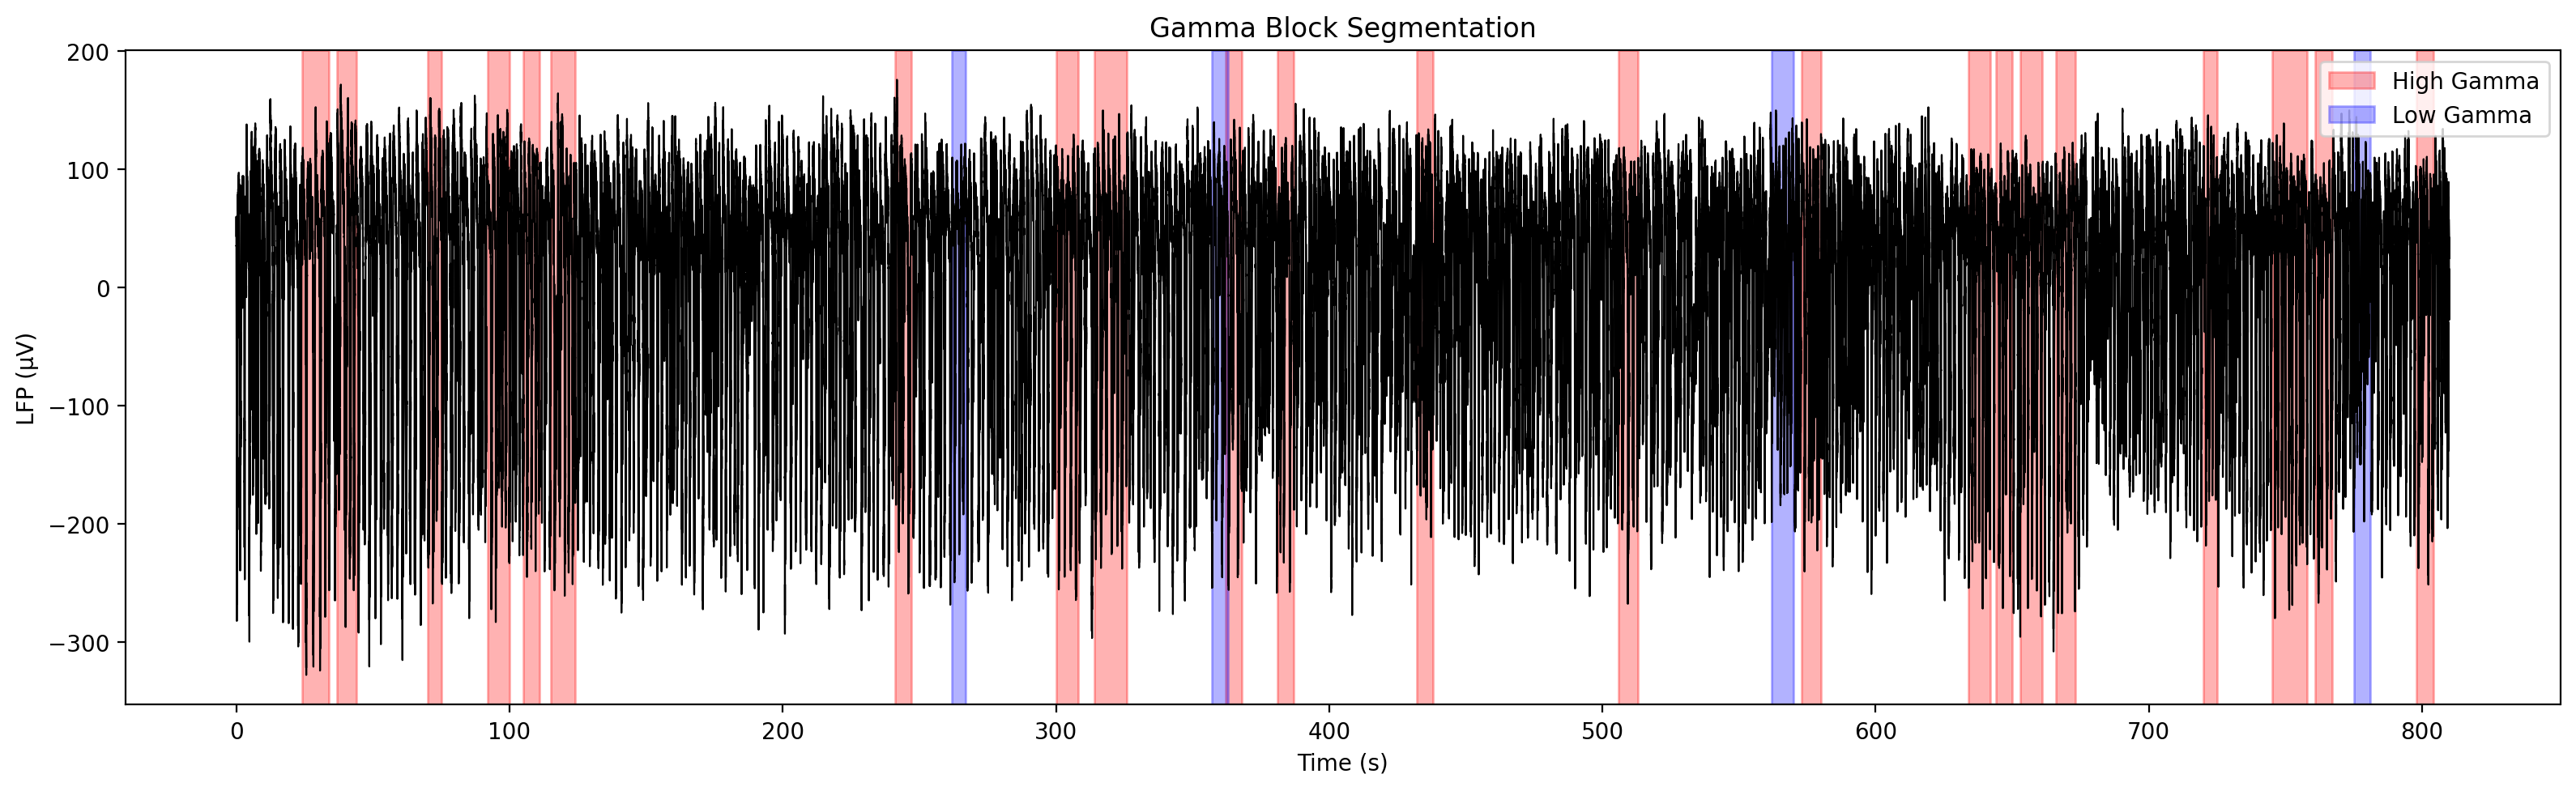

[Blocks]
High Gamma: 22 blocks | Total duration: 162.00 s
Low Gamma:  4 blocks | Total duration: 25.00 s


In [14]:
# Segment windows and blocks
high_windows_welch, low_windows_welch, high_blocks_welch, low_blocks_welch = segment_gamma_epochs(
    summary_df_welch,
    win_times_welch,
    lfp_signal,
    fs,
    window_len_sec=window_len_sec,
    gamma_band_name="gamma",
    visualize=True
)


### Visualize specparam results for low vs high gamma windows 

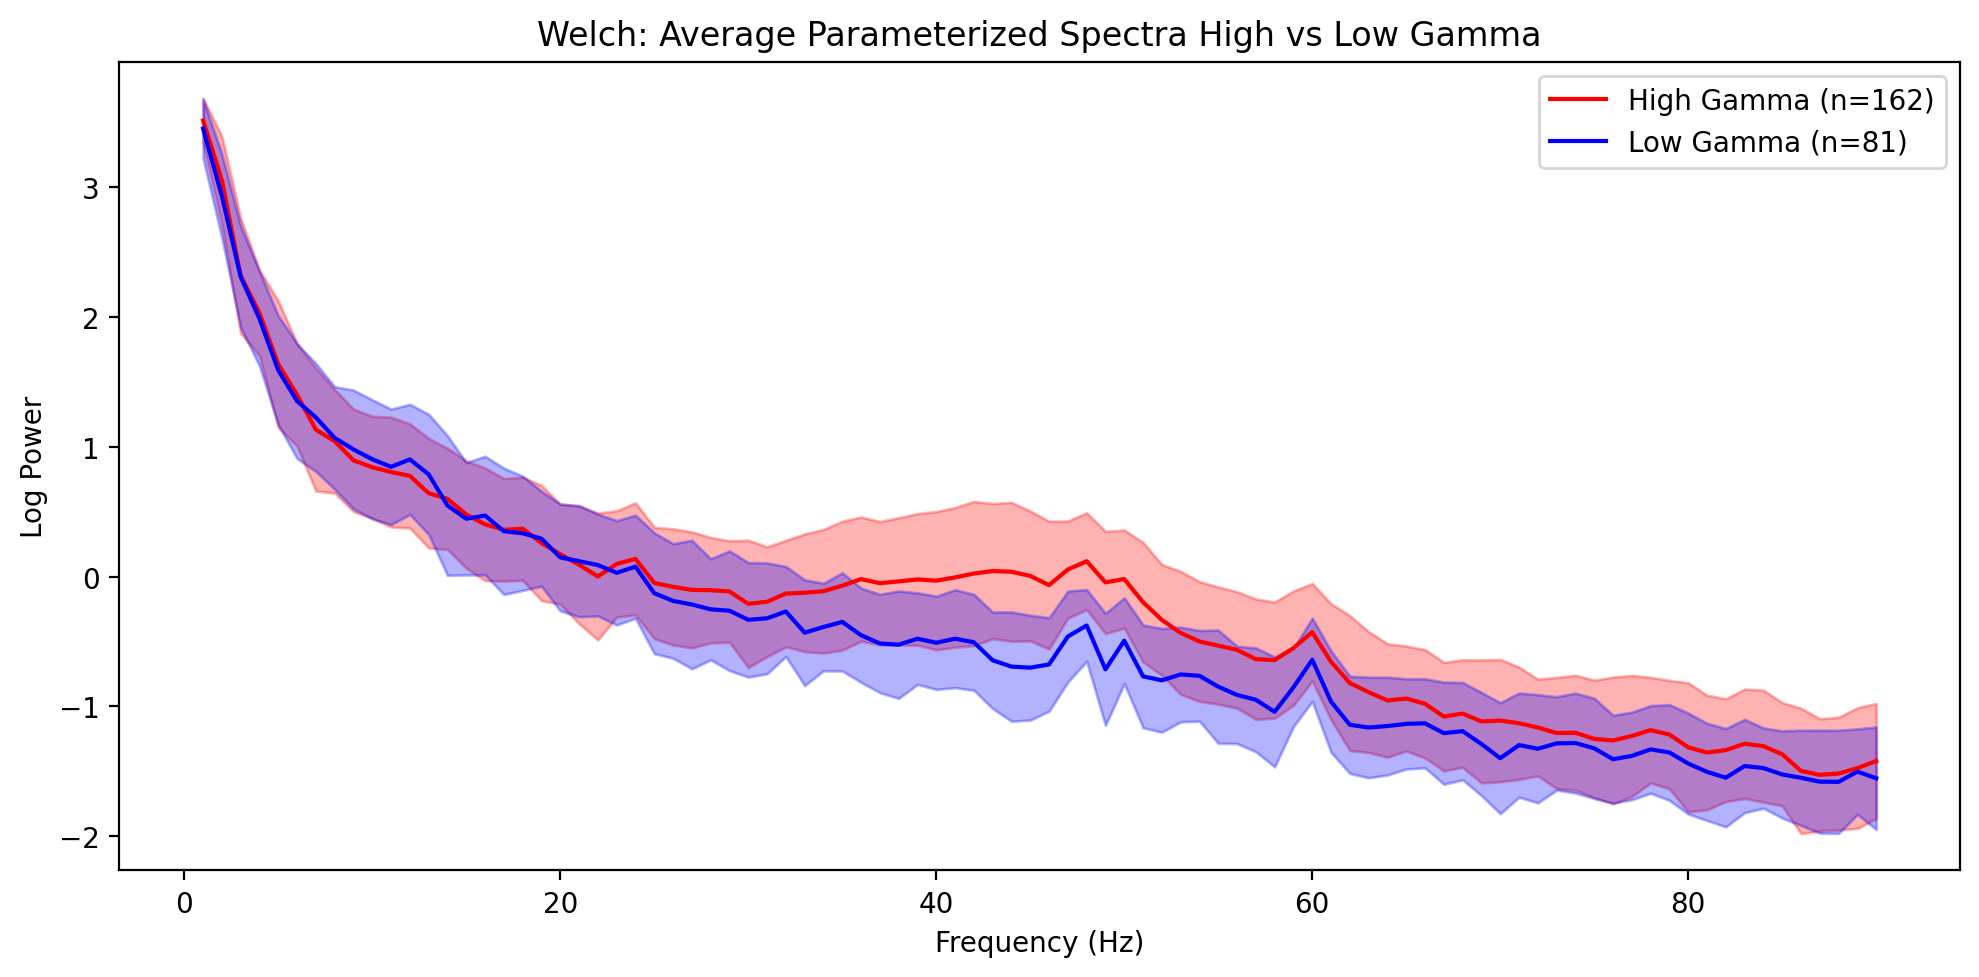

In [15]:
plot_param_spectra_high_low(
    model_welch,
    high_windows_welch,     
    low_windows_welch,       
    window_times=win_times_welch,
    title="Welch: Average Parameterized Spectra High vs Low Gamma"
)


### Replicate with multitapers

In [ ]:
# Use multitaper method instead of Welch
model_mt, freqs_mt, win_times_mt = compute_lfp_windows(
    lfp_signal=lfp_filt,
    fs=lfp_fs,
    method='multitaper',  
    window_length_sec=window_len_sec,
    step_size_sec=step_size_sec,
    freq_range=(1, 90),
    fooof_params={"max_n_peaks": 4, "verbose": False},
    multitaper_params={"bandwidth": 4}  
)

In [ ]:
model_mt.report(peak_org=bands)

In [ ]:
# Get summary df
summary_df_mt = model_mt.to_df(peak_org=bands)

In [ ]:
high_windows_mt, low_windows_mt, high_blocks_mt, low_blocks_mt = segment_gamma_epochs(summary_df_mt, win_times_mt, lfp_filt, lfp_fs)

In [ ]:
plot_param_spectra_high_low(
    model_mt,
    high_windows_mt,      
    low_windows_mt,       
    window_times=win_times_mt,
    title="MT: Average Parameterized Spectra High vs Low Gamma"
)


### Compare blocks assigned by both methods 

In [ ]:
# Overlap version (AND logic)
high_overlap_blocks, low_overlap_blocks = get_and_plot_method_comparison_blocks(
    lfp_signal, fs,
    high_blocks_welch, low_blocks_welch,
    high_blocks_mt, low_blocks_mt,
    mode="overlap"
)

# Non-Contradictory version (OR minus conflicts)
high_nc_blocks, low_nc_blocks = get_and_plot_method_comparison_blocks(
    lfp_signal, fs,
    high_blocks_welch, low_blocks_welch,
    high_blocks_mt, low_blocks_mt,
    mode="noncontradictory"
)


# B) Save high and low blocks as bin files for kilosort  - update

In [ ]:
save_bin_path = "/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spe1_lfp_bins_c42"


save_lfp_blocks_to_bin(
    lfp_signal=lfp_signal,
    fs=fs,
    overlap_high=high_overlap_blocks,
    overlap_low=low_overlap_blocks,
    output_dir=save_bin_path
)

# Step 2: Analyze patch spikes from high vs low blocks 

In [ ]:
#parameterize all spikes
spk_thresh = 10
sp = Spike(thresh_amp=spk_thresh, window_length=(5., 5.), smooth_frac=.01)

In [ ]:
sp.fit(patch_filt, patch_fs, n_jobs=-1, progress=tqdm)

In [ ]:
sp.plot()

In [ ]:
sp.filter_features()  # Applies default filters in-place

In [ ]:
df_features = sp.df_features

#add columns for spike times, both in idx and ms
df_features['spk_times_idx'] = sp.spike_inds
df_features['spk_times_ms'] = patch_times[sp.spike_inds]
df_features['spk_id'] = range(len(df_features))

In [ ]:
# 1) Overlap-based labeling
spike_df_overlap = label_spikes_method_comparison(df_features, high_overlap_blocks, low_overlap_blocks, mode="overlap")

# 2) Non-Contradictory-based labeling
spike_df_nc = label_spikes_method_comparison(df_features, high_nc_blocks, low_nc_blocks, mode="noncontradictory")

# 3) High vs Rest labeling
spike_df_high_rest = label_spikes_method_comparison(df_features, high_nc_blocks, mode="high_vs_rest")


In [ ]:
plot_spike_groups_from_labels(
    sp,
    spike_df_nc,
    label_column="method_block_label",
    label_groups=["high_noncontradictory", "low_noncontradictory"],
    group_names=["High Non-Contradictory", "Low Non-Contradictory"]
)


In [ ]:
plot_spike_groups_from_labels(
    sp,
    spike_df_high_rest,
    label_column="method_block_label",
    label_groups=["high", "rest"],
    group_names=["High Gamma", "All Other Spikes"]
)


In [ ]:
compare_spike_params_groups(
    spike_df_nc,
    group_col="method_block_label",
    groups=("high_noncontradictory", "low_noncontradictory"),
    params=spike_df_nc.columns[:-4]
)


In [ ]:
compare_spike_params_groups(
    spike_df_high_rest,
    group_col="method_block_label",
    groups=("high", "rest"),
    params=spike_df_high_rest.columns[:-4]
)

